# Laboratorium 2 - Metoda najmniejszych kwadratów

In [1]:
import numpy as np
import matplotlib.pyplot as plt

(a) i (b) - otwarcie zbioru danych z pliku .txt i podzielenie go na zbiór treningowy i testowy - pierwsze 463715 przykładów to zbiór treningowy, natomiast pozostałe 51630 to zbiór testowy.

In [2]:
data = np.loadtxt("YearPredictionMSD.txt", delimiter=",")
train_data = data[:463715]
test_data = data[463716:]

(c) - narysowanie histogramu ilutstrującego liczbę piosenek wydanych w danym przedziale czasowym

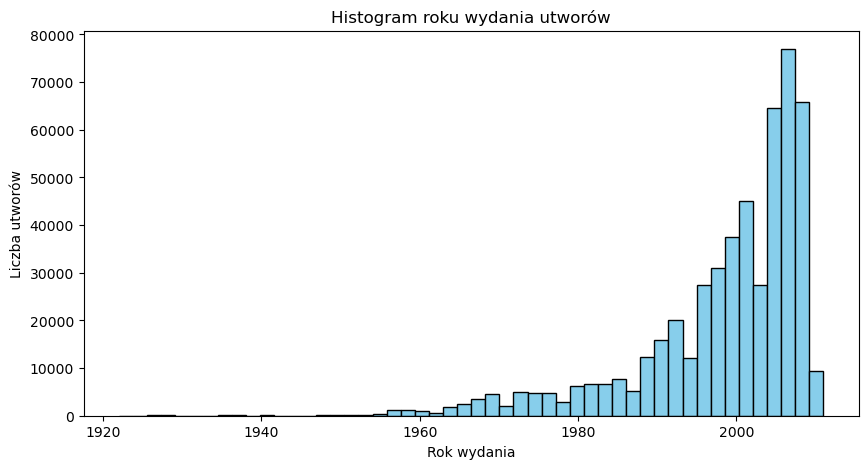

In [3]:
release_years = data[:, 0]
plt.figure(figsize=(10, 5))
plt.hist(release_years, bins=50, color='skyblue', edgecolor='black') # bins to liczba "koszyków"
plt.title('Histogram roku wydania utworów')
plt.xlabel('Rok wydania')
plt.ylabel('Liczba utworów')
plt.show()

(c) - narysowanie wykresu liniowego ilustrującego akumulowaną liczbę wydanych utworów w danym roku

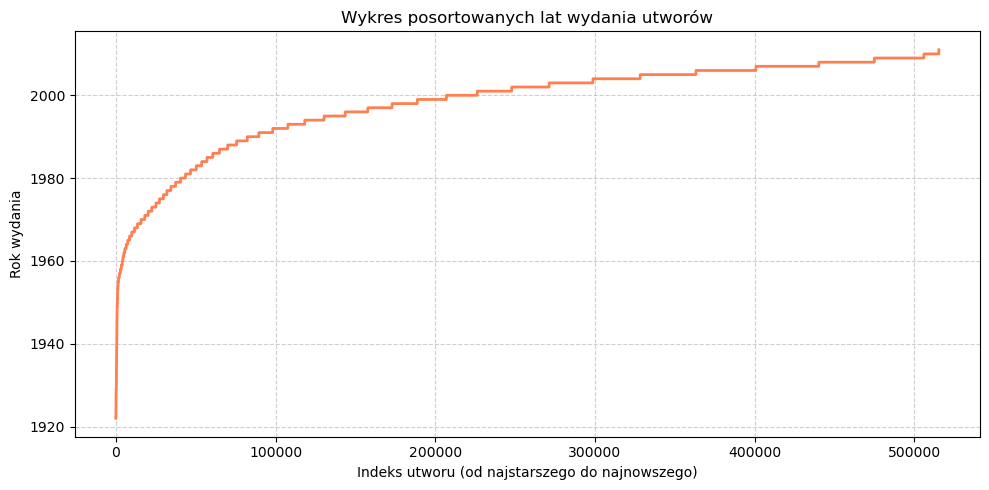

In [4]:
sorted_years = np.sort(release_years)

plt.figure(figsize=(10, 5))

plt.plot(sorted_years, color='coral', linewidth=2)

plt.title('Wykres posortowanych lat wydania utworów')
plt.xlabel('Indeks utworu (od najstarszego do najnowszego)')
plt.ylabel('Rok wydania')

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

(d)

In [5]:
import numpy as np

y_train = train_data[:, 0]
X_train = train_data[:, 1:]

y_test = test_data[:, 0]
X_test = test_data[:, 1:]

ones_train = np.ones((X_train.shape[0], 1))
ones_test = np.ones((X_test.shape[0], 1))

X_train_ols = np.hstack((ones_train, X_train))
X_test_ols = np.hstack((ones_test, X_test))

X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

y_min = y_train.min()
y_max = y_train.max()

X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled = (X_test - X_min) / (X_max - X_min) 

y_train_scaled = (y_train - y_min) / (y_max - y_min)
y_test_scaled = (y_test - y_min) / (y_max - y_min)

X_train_scaled_ols = np.hstack((ones_train, X_train_scaled))
X_test_scaled_ols = np.hstack((ones_test, X_test_scaled))

(e)

In [7]:
import numpy as np

X_T = X_train_ols.T

A_matrix = X_T @ X_train_ols

B_vector = X_T @ y_train

weights_unscaled = np.linalg.solve(A_matrix, B_vector)

print(f"Liczba obliczonych wag: {len(weights_unscaled)}") 
print(f"Wyraz wolny (w0): {weights_unscaled[0]}")
print(f"Kilka pierwszych wag cech: {weights_unscaled[1:5]}")

Liczba obliczonych wag: 91
Wyraz wolny (w0): 1951.1221815924844
Kilka pierwszych wag cech: [ 0.87343914 -0.05581652 -0.0434526   0.00351252]


(f)

In [8]:
import numpy as np
import scipy.linalg as la


weights_svd, _, _, _ = la.lstsq(X_train_ols, y_train)

print("Obliczono wagi metodą SVD.")

lambda_val = 0.01

A_matrix = X_train_ols.T @ X_train_ols
B_vector = X_train_ols.T @ y_train

I = np.eye(A_matrix.shape[0])

I[0, 0] = 0

A_matrix_regularized = A_matrix + (lambda_val * I)

weights_regularized = np.linalg.solve(A_matrix_regularized, B_vector)

print("Obliczono wagi metodą równania normalnego z regularyzacją.")

print(np.linalg.norm(weights_unscaled - weights_svd))

Obliczono wagi metodą SVD.
Obliczono wagi metodą równania normalnego z regularyzacją.
1.3696616630583816e-09


(g)

In [9]:
import numpy as np

A_unscaled = X_train_ols.T @ X_train_ols
A_scaled = X_train_scaled_ols.T @ X_train_scaled_ols

cond_unscaled = np.linalg.cond(A_unscaled)
cond_scaled = np.linalg.cond(A_scaled)

print(f"Współczynnik uwarunkowania (bez normalizacji): {cond_unscaled:.2e}")
print(f"Współczynnik uwarunkowania (z normalizacją): {cond_scaled:.2e}")

Współczynnik uwarunkowania (bez normalizacji): 3.87e+09
Współczynnik uwarunkowania (z normalizacją): 2.15e+06


(h)

In [10]:
import numpy as np

A_scaled = X_train_scaled_ols.T @ X_train_scaled_ols
B_scaled = X_train_scaled_ols.T @ y_train_scaled
weights_scaled = np.linalg.solve(A_scaled, B_scaled)

y_pred_unscaled = X_test_ols @ weights_unscaled

mae_unscaled = np.mean(np.abs(y_test - y_pred_unscaled))

y_pred_scaled_raw = X_test_scaled_ols @ weights_scaled

y_pred_scaled_reversed = y_pred_scaled_raw * (y_max - y_min) + y_min

mae_scaled = np.mean(np.abs(y_test - y_pred_scaled_reversed))

print(f"Średni błąd (MAE) dla danych nieznormalizowanych: {mae_unscaled:.2f} lat")
print(f"Średni błąd (MAE) dla danych znormalizowanych: {mae_scaled:.2f} lat")

Średni błąd (MAE) dla danych nieznormalizowanych: 6.80 lat
Średni błąd (MAE) dla danych znormalizowanych: 6.80 lat


(i)

In [11]:
import numpy as np

rozmiar_paczki = 100000
liczba_wierszy = X_train_ols.shape[0]

liczba_cech = X_train_ols.shape[1]
H = np.zeros((liczba_cech, liczba_cech))
b = np.zeros(liczba_cech)

print("--- Uczenie Inkrementacyjne (Filtr Kalmana) ---")

iteracja = 1
for start_idx in range(0, liczba_wierszy, rozmiar_paczki):
    end_idx = min(start_idx + rozmiar_paczki, liczba_wierszy)
    
    A_k = X_train_ols[start_idx:end_idx]
    y_k = y_train[start_idx:end_idx]
    
    H += A_k.T @ A_k
    b += A_k.T @ y_k
    
    wagi_k = np.linalg.solve(H, b)
    
    y_pred = X_test_ols @ wagi_k
    
    mae = np.mean(np.abs(y_test - y_pred))
    
    liczba_elementow = end_idx - start_idx
    print(f"Paczka {iteracja} (wiersze {start_idx:06d}-{end_idx-1:06d}, rozmiar: {liczba_elementow}): MAE = {mae:.4f} lat")
    
    iteracja += 1

--- Uczenie Inkrementacyjne (Filtr Kalmana) ---
Paczka 1 (wiersze 000000-099999, rozmiar: 100000): MAE = 6.8460 lat
Paczka 2 (wiersze 100000-199999, rozmiar: 100000): MAE = 6.8064 lat
Paczka 3 (wiersze 200000-299999, rozmiar: 100000): MAE = 6.7997 lat
Paczka 4 (wiersze 300000-399999, rozmiar: 100000): MAE = 6.8010 lat
Paczka 5 (wiersze 400000-463714, rozmiar: 63715): MAE = 6.8004 lat


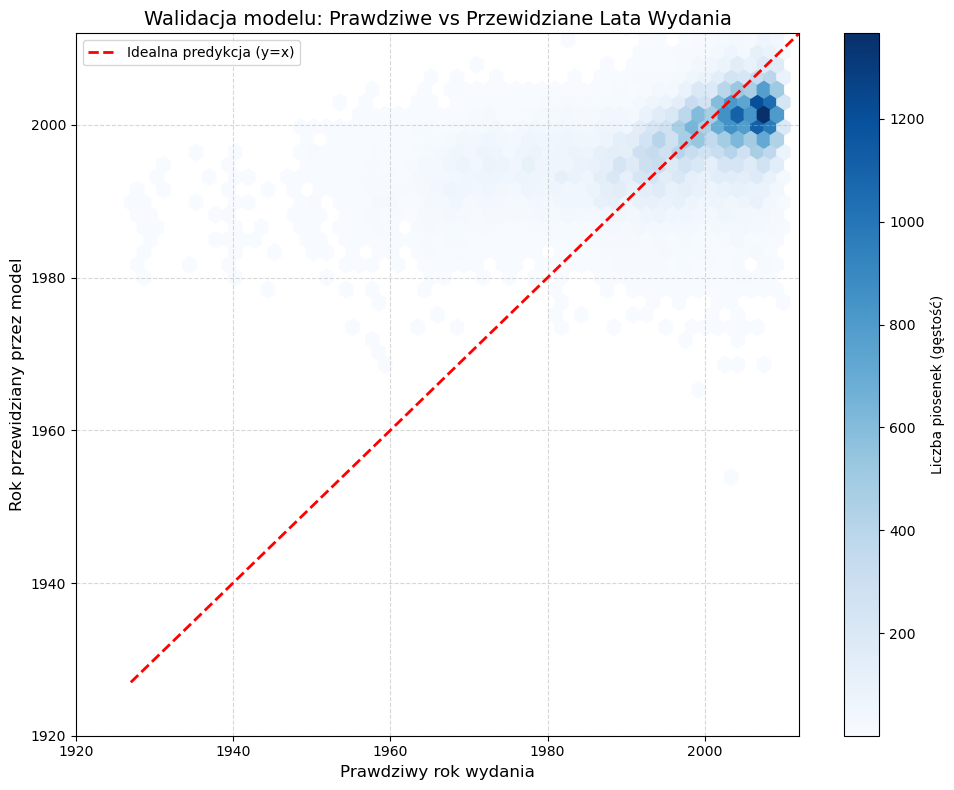

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

hb = plt.hexbin(y_test, y_pred_scaled_reversed, gridsize=50, cmap='Blues', mincnt=1)

cb = plt.colorbar(hb, label='Liczba piosenek (gęstość)')

min_year = int(np.min([y_test.min(), y_pred_scaled_reversed.min()]))
max_year = int(np.max([y_test.max(), y_pred_scaled_reversed.max()]))
ideal_range = [min_year, max_year]
plt.plot(ideal_range, ideal_range, color='red', linestyle='--', linewidth=2, label='Idealna predykcja (y=x)')

plt.title('Walidacja modelu: Prawdziwe vs Przewidziane Lata Wydania', fontsize=14)
plt.xlabel('Prawdziwy rok wydania', fontsize=12)
plt.ylabel('Rok przewidziany przez model', fontsize=12)
plt.legend(loc='upper left')

plt.xlim(1920, 2012)
plt.ylim(1920, 2012)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

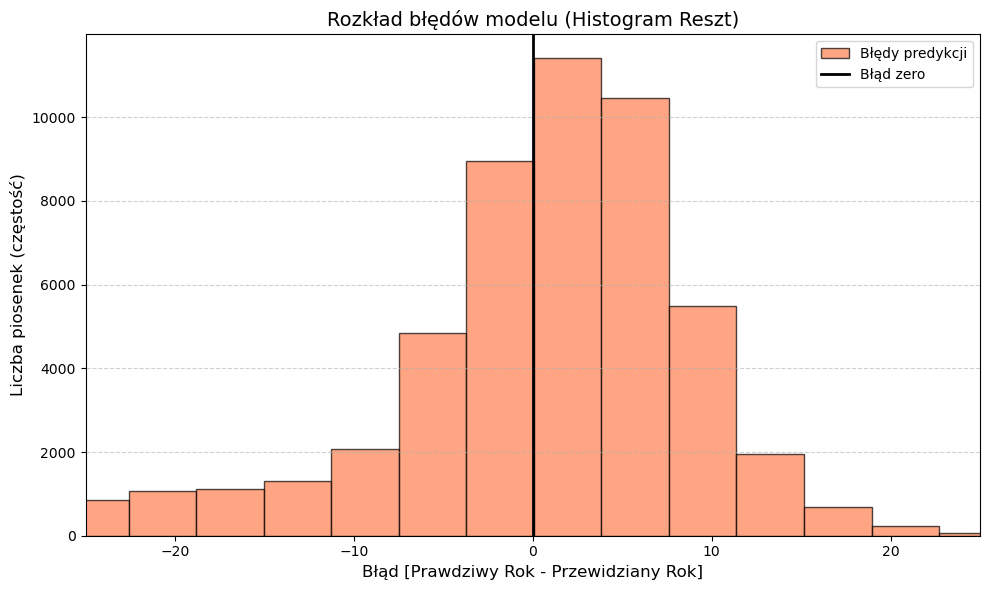

In [13]:
residuals = y_test - y_pred_scaled_reversed

plt.figure(figsize=(10, 6))

plt.hist(residuals, bins=30, color='coral', edgecolor='black', alpha=0.7, label='Błędy predykcji')

plt.axvline(x=0, color='black', linestyle='-', linewidth=2, label='Błąd zero')

plt.title('Rozkład błędów modelu (Histogram Reszt)', fontsize=14)
plt.xlabel('Błąd [Prawdziwy Rok - Przewidziany Rok]', fontsize=12)
plt.ylabel('Liczba piosenek (częstość)', fontsize=12)
plt.legend()

plt.xlim(-25, 25)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Paczka 1: MAE = 6.8460
Paczka 2: MAE = 6.8064
Paczka 3: MAE = 6.7997
Paczka 4: MAE = 6.8010
Paczka 5: MAE = 6.8004


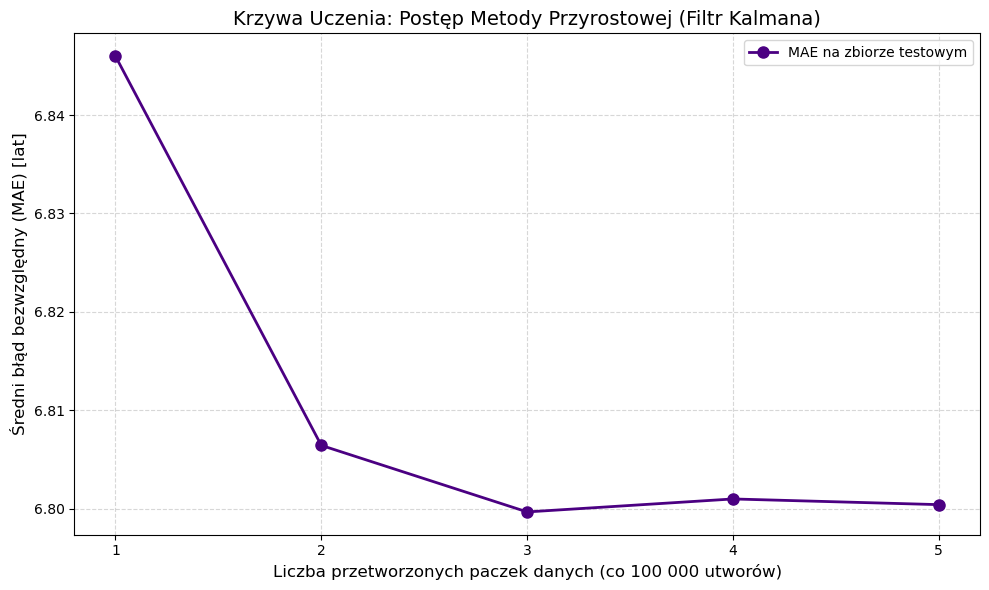

In [14]:
batch_size = 100000
total_rows = X_train_ols.shape[0]
num_features = X_train_ols.shape[1]

H = np.zeros((num_features, num_features))
b = np.zeros(num_features)

mae_history = [] 

batch_number = 1
for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    
    A_k = X_train_ols[start_idx:end_idx]
    y_k = y_train[start_idx:end_idx]
    
    H += A_k.T @ A_k
    b += A_k.T @ y_k
    weights_k = np.linalg.solve(H, b)
    
    y_pred = X_test_ols @ weights_k
    mae = np.mean(np.abs(y_test - y_pred))

    mae_history.append(mae) 
    
    print(f"Paczka {batch_number}: MAE = {mae:.4f}")
    batch_number += 1

plt.figure(figsize=(10, 6))

batches_axis = np.arange(1, len(mae_history) + 1)
plt.plot(batches_axis, mae_history, marker='o', linestyle='-', color='indigo', markersize=8, linewidth=2, label='MAE na zbiorze testowym')

plt.title('Krzywa Uczenia: Postęp Metody Przyrostowej (Filtr Kalmana)', fontsize=14)
plt.xlabel('Liczba przetworzonych paczek danych (co 100 000 utworów)', fontsize=12)
plt.ylabel('Średni błąd bezwzględny (MAE) [lat]', fontsize=12)
plt.legend()

plt.xticks(batches_axis)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()